2025-12-29 11-00-59
Outputs will be written to: results/run_2025-12-29 11-00-59
Saved a copy of the config : results/run_2025-12-29 11-00-59/config_copy.yaml
Inputs shape: (39, 4)
Outputs shape: (39,)
First 20 rows of raw data:
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27      0.577766     0.428772     0.425826     0.249007        -4.025542    file
36      0.572134     0.415866     0.465114     0.491781        -4.550363  week-7
30      0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
38      0.573921     0.509823     0.408512     0.282146        -4.847336  week-9
31      0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32      0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24      0.326076     0.472367     0.453192     0.105887        -6.702089    file
34      0.343612     0.592249     0.651353     0.444513        -7.221570  week-5
35      0.445393     0.174795     0.339088 

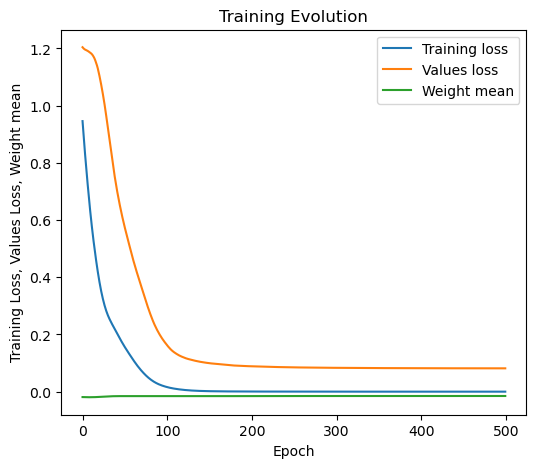

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (3000, 4)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.55224298, 0.47835095, 0.44165724, 0.21379679]), 'score': 0.282680402715876, 'dim': 4, 'predicted_y': -4.2488775}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.55224298, 0.47835095, 0.44165724, 0.21379679]), 'score': 0.282680402715876, 'dim': 4, 'predicted_y': -4.2488775}
{'method': 'PI', 'xi': 0.3, 'kappa': None, 'x': array([0.34372347, 0.34559055, 0.48289265, 0.38763367]), 'score': 0.01538598036399107, 'dim': 4, 'predicted_y': -5.802393}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.34372347, 0.34559055, 0.48289265, 0.38763367]), 'score': 0.021276974962774975, 'dim': 

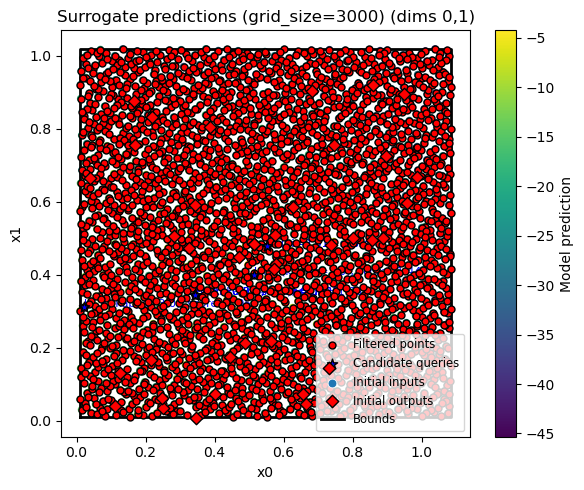

Saved dataframe to: results/run_2025-12-29 11-00-59/df_grid_3000_stride8_None_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.02307133, 0.31145587, 0.66880548, 0.75211593]), 'score': 1.9557990177223235, 'dim': 4, 'predicted_y': -10.705734}
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source  opt-place-score-scaled
0       0.023071     0.311456     0.668805     0.752116         1.955799  week-x               10.000000
1       0.343723     0.345591     0.482893     0.387634         1.658024  week-x                8.477474
2       0.513114     0.399799     0.402821     0.155917         1.446789  week-x                7.397434
3       0.552243     0.478351     0.441657     0.213797         0.282680  week-x                1.445345
4       0.552243     0.478351     0.441657     0.213797         0.282680  week-x                1.445345
5       0.343723     0.345591     0.482893     0.387634         0.021277  week

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))